In [ ]:
!pip install -qU rfdetr supervision

In [ ]:
# === Cell 1: Definición de la clase VideoInference ===
import torch
import cv2
import pandas as pd
from argparse import Namespace
from tqdm import tqdm
from rfdetr import RFDETRBase

class VideoInference:
    def __init__(self, model_path):
        # Permitir deserializar argparse.Namespace
        torch.serialization.add_safe_globals([Namespace])
        # Cargar checkpoint completo (pesos + metadata)
        ckpt = torch.load(model_path, map_location="cpu", weights_only=False)
        raw_names = getattr(ckpt["args"], "class_names", [])
        # Usar solo el número real de clases (longitud de raw_names)
        num_classes = len(raw_names)

        # Instanciar el modelo con las clases correctas
        device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model = RFDETRBase(
            pretrain_weights=model_path,
            num_classes=num_classes,
            class_names=raw_names,
            device=device
        )
        # Guardar nombres para mapear luego
        self.class_names = raw_names

    def process(self, video_path, threshold=0.5):
        """
        Procesa un vídeo entero y devuelve un DataFrame con las columnas:
        Frame, ClassName, BBox.
        Muestra una barra de progreso por frame.
        """
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        results = []
        frame_idx = 0

        with tqdm(total=total_frames, desc="Procesando frames") as pbar:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                detections = self.model.predict(frame, threshold=threshold)
                for box, cid, conf in zip(detections.xyxy,
                                          detections.class_id,
                                          detections.confidence):
                    x1, y1, x2, y2 = map(float, box.tolist())
                    # Ajustar índice restando 1 para alinear con class_names
                    idx = cid - 1
                    name = (self.class_names[idx]
                            if 0 <= idx < len(self.class_names)
                            else f"class_{cid}")
                    results.append({
                        "Frame":     frame_idx,
                        "ClassName": name,
                        "BBox":      [x1, y1, x2, y2]
                    })

                frame_idx += 1
                pbar.update(1)

        cap.release()
        df = pd.DataFrame(results, columns=["Frame", "ClassName", "BBox"])
        return df


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# === Cell 2: Ejemplo de uso ===
MODEL_PATH = "/content/drive/MyDrive/checkpoint0019.pth"
VIDEO_PATH = "/content/drive/MyDrive/MillonariosAm.mp4"

vi = VideoInference(MODEL_PATH)
df = vi.process(VIDEO_PATH, threshold=0.5)

print(df.head())


Loading pretrain weights


Procesando frames: 100%|██████████| 739/739 [00:59<00:00, 12.40it/s]

   Frame ClassName                                               BBox
0      0   jugador  [177.64614868164062, 278.5949401855469, 220.02...
1      0   jugador  [940.1264038085938, 252.48336791992188, 984.42...
2      0   jugador  [812.1710815429688, 391.4423522949219, 857.592...
3      0   jugador  [52.62643814086914, 301.9477844238281, 103.787...
4      0   jugador  [449.4344787597656, 225.01454162597656, 488.07...


In [ ]:
# === Cell 2: Ejemplo de uso ===
VIDEO_PATH       = "/content/drive/MyDrive/MillonariosAm.mp4"
OUTPUT_VIDEO     = "/content/drive/MyDrive/VideoAnotado.mp4"

# 'df' debe existir en el entorno (resultado de VideoInference.process)
#annotate_video_from_df(VIDEO_PATH, df, OUTPUT_VIDEO)

print("✅ Vídeo anotado guardado en:", OUTPUT_VIDEO)


✅ Vídeo anotado guardado en: /content/drive/MyDrive/VideoAnotado.mp4


In [ ]:
import cv2
import os

def save_crops_from_df(video_path, df, output_dir="crops_resnet", max_crops=400):
    os.makedirs(output_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)

    saved = 0
    for _, row in df.iterrows():
        if saved >= max_crops:
            break

        frame_id = int(row["Frame"])
        class_name = row["ClassName"]
        x1, y1, x2, y2 = map(int, row["BBox"])

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
        ret, frame = cap.read()
        if not ret:
            continue

        crop = frame[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        crop_filename = f"{saved:04d}_{class_name}.jpg"
        cv2.imwrite(os.path.join(output_dir, crop_filename), crop)
        saved += 1

    cap.release()
    print(f"✅ Se guardaron {saved} crops en {output_dir}")


In [ ]:
df

,Frame,ClassName,BBox
0,0,jugador,"[177.64614868164062, 278.5949401855469, 220.02..."
1,0,jugador,"[940.1264038085938, 252.48336791992188, 984.42..."
2,0,jugador,"[812.1710815429688, 391.4423522949219, 857.592..."
3,0,jugador,"[52.62643814086914, 301.9477844238281, 103.787..."
4,0,jugador,"[449.4344787597656, 225.01454162597656, 488.07..."
...,...,...,...
11529,738,jugador,"[728.8328857421875, 338.194091796875, 773.2380..."
11530,738,jugador,"[635.4104614257812, 324.90484619140625, 690.51..."
11531,738,jugador,"[383.1383972167969, 205.45635986328125, 426.82..."
11532,738,jugador,"[29.445457458496094, 274.7135925292969, 62.177..."


Crop 1:


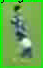

Crop 2:


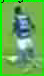

Crop 3:


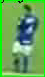

Crop 4:


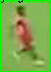

Crop 5:


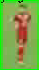

Crop 6:


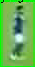

Crop 7:


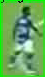

Crop 8:


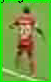

Crop 9:


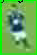

Crop 10:


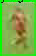

Crop 11:


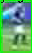

Crop 12:


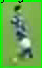

Crop 13:


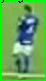

Crop 14:


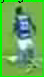

Crop 15:


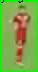

Crop 16:


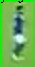

Crop 17:


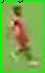

Crop 18:


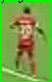

Crop 19:


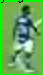

Crop 20:


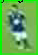

Crop 21:


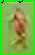

Crop 22:


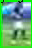

Crop 23:


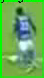

Crop 24:


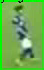

Crop 25:


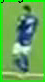

Crop 26:


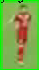

Crop 27:


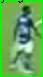

Crop 28:


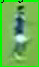

Crop 29:


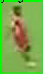

Crop 30:


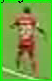

Crop 31:


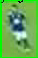

Crop 32:


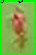

Crop 33:


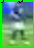

Crop 34:


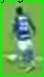

Crop 35:


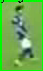

Crop 36:


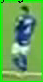

Crop 37:


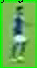

Crop 38:


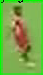

Crop 39:


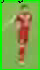

Crop 40:


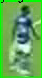

Crop 41:


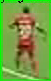

Crop 42:


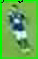

Crop 43:


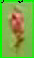

Crop 44:


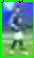

Crop 45:


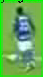

Crop 46:


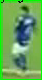

Crop 47:


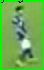

Crop 48:


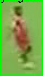

Crop 49:


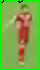

Crop 50:


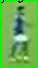

Crop 51:


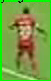

Crop 52:


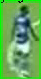

Crop 53:


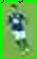

Crop 54:


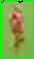

Crop 55:


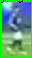

Crop 56:


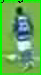

Crop 57:


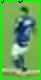

Crop 58:


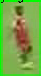

Crop 59:


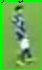

Crop 60:


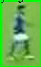

Crop 61:


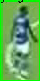

Crop 62:


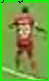

Crop 63:


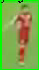

Crop 64:


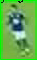

Crop 65:


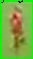

Crop 66:


Crop 67:


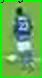

Crop 68:


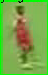

Crop 69:


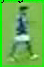

Crop 70:


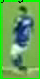

Crop 71:


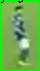

Crop 72:


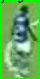

Crop 73:


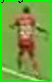

Crop 74:


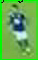

Crop 75:


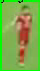

Crop 76:


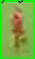

Crop 77:


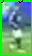

Crop 78:


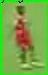

Crop 79:


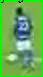

Crop 80:


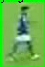

Crop 81:


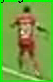

Crop 82:


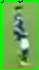

Crop 83:


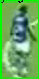

Crop 84:


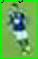

Crop 85:


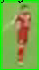

Crop 86:


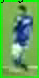

Crop 87:


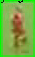

Crop 88:


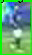

Crop 89:


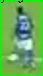

Crop 90:


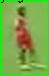

Crop 91:


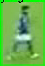

Crop 92:


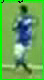

Crop 93:


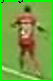

Crop 94:


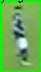

Crop 95:


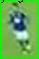

Crop 96:


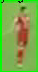

Crop 97:


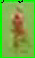

Crop 98:


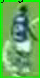

Crop 99:


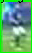

Crop 100:


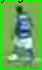

Crop 101:


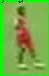

Crop 102:


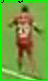

Crop 103:


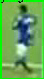

Crop 104:


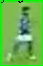

Crop 105:


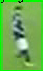

Crop 106:


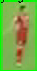

Crop 107:


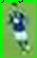

Crop 108:


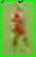

Crop 109:


Crop 110:


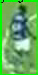

Crop 111:


Crop 112:


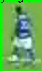

Crop 113:


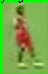

Crop 114:


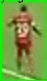

Crop 115:


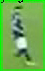

Crop 116:


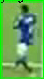

Crop 117:


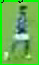

Crop 118:


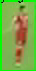

Crop 119:


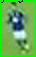

Crop 120:


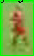

Crop 121:


Crop 122:


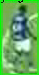

Crop 123:


Crop 124:


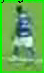

Crop 125:


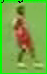

Crop 126:


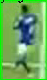

Crop 127:


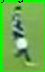

Crop 128:


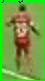

Crop 129:


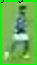

Crop 130:


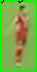

Crop 131:


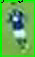

Crop 132:


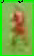

Crop 133:


Crop 134:


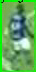

Crop 135:


Crop 136:


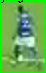

Crop 137:


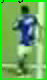

Crop 138:


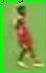

Crop 139:


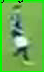

Crop 140:


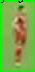

Crop 141:


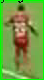

Crop 142:


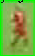

Crop 143:


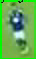

Crop 144:


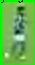

Crop 145:


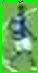

Crop 146:


Crop 147:


Crop 148:


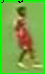

Crop 149:


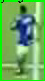

Crop 150:


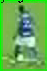

Crop 151:


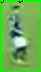

Crop 152:


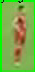

Crop 153:


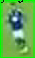

Crop 154:


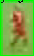

Crop 155:


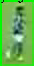

Crop 156:


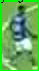

Crop 157:


Crop 158:


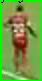

Crop 159:


Crop 160:


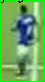

Crop 161:


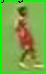

Crop 162:


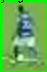

Crop 163:


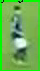

Crop 164:


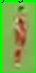

Crop 165:


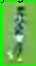

Crop 166:


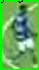

Crop 167:


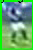

Crop 168:


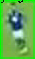

Crop 169:


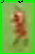

Crop 170:


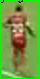

Crop 171:


Crop 172:


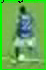

Crop 173:


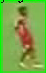

Crop 174:


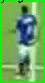

Crop 175:


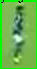

Crop 176:


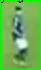

Crop 177:


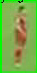

Crop 178:


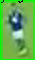

Crop 179:


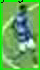

Crop 180:


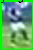

Crop 181:


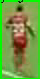

Crop 182:


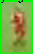

Crop 183:


Crop 184:


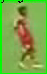

Crop 185:


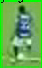

Crop 186:


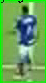

Crop 187:


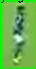

Crop 188:


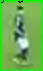

Crop 189:


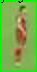

Crop 190:


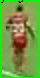

Crop 191:


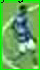

Crop 192:


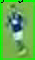

Crop 193:


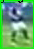

Crop 194:


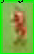

Crop 195:


Crop 196:


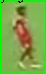

Crop 197:


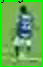

Crop 198:


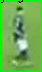

Crop 199:


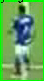

Crop 200:


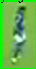

Crop 201:


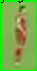

Crop 202:


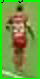

Crop 203:


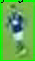

Crop 204:


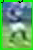

Crop 205:


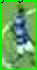

Crop 206:


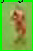

Crop 207:


Crop 208:


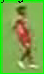

Crop 209:


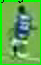

Crop 210:


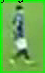

Crop 211:


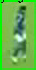

Crop 212:


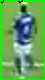

Crop 213:


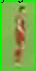

Crop 214:


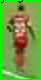

Crop 215:


Crop 216:


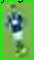

Crop 217:


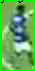

Crop 218:


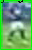

Crop 219:


Crop 220:


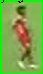

Crop 221:


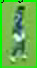

Crop 222:


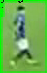

Crop 223:


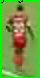

Crop 224:


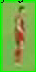

Crop 225:


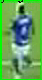

Crop 226:


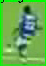

Crop 227:


Crop 228:


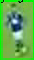

Crop 229:


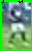

Crop 230:


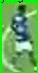

Crop 231:


Crop 232:


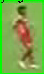

Crop 233:


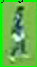

Crop 234:


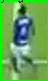

Crop 235:


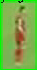

Crop 236:


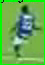

Crop 237:


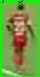

Crop 238:


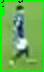

Crop 239:


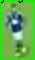

Crop 240:


Crop 241:


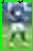

Crop 242:


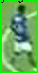

Crop 243:


Crop 244:


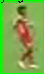

Crop 245:


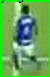

Crop 246:


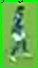

Crop 247:


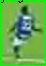

Crop 248:


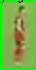

Crop 249:


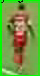

Crop 250:


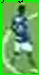

Crop 251:


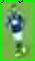

Crop 252:


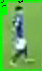

Crop 253:


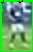

Crop 254:


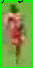

Crop 255:


Crop 256:


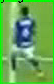

Crop 257:


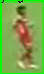

Crop 258:


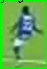

Crop 259:


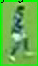

Crop 260:


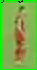

Crop 261:


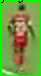

Crop 262:


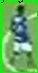

Crop 263:


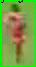

Crop 264:


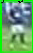

Crop 265:


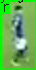

Crop 266:


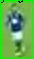

Crop 267:


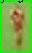

Crop 268:


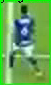

Crop 269:


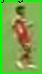

Crop 270:


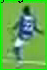

Crop 271:


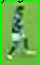

Crop 272:


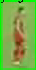

Crop 273:


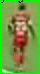

Crop 274:


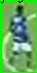

Crop 275:


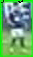

Crop 276:


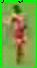

Crop 277:


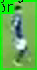

Crop 278:


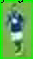

Crop 279:


Crop 280:


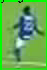

Crop 281:


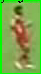

Crop 282:


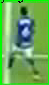

Crop 283:


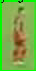

Crop 284:


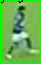

Crop 285:


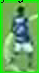

Crop 286:


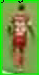

Crop 287:


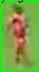

Crop 288:


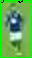

Crop 289:


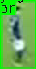

Crop 290:


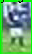

Crop 291:


Crop 292:


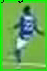

Crop 293:


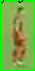

Crop 294:


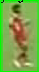

Crop 295:


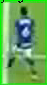

Crop 296:


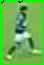

Crop 297:


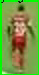

Crop 298:


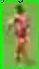

Crop 299:


Crop 300:


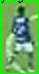

Crop 301:


Crop 302:


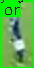

Crop 303:


Crop 304:


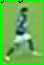

Crop 305:


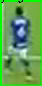

Crop 306:


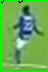

Crop 307:


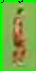

Crop 308:


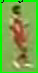

Crop 309:


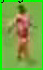

Crop 310:


Crop 311:


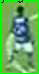

Crop 312:


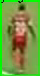

Crop 313:


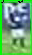

Crop 314:


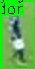

Crop 315:


Crop 316:


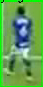

Crop 317:


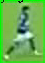

Crop 318:


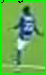

Crop 319:


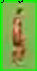

Crop 320:


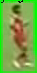

Crop 321:


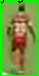

Crop 322:


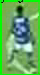

Crop 323:


Crop 324:


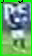

Crop 325:


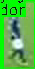

Crop 326:


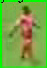

Crop 327:


Crop 328:


Crop 329:


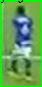

Crop 330:


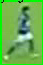

Crop 331:


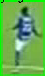

Crop 332:


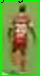

Crop 333:


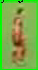

Crop 334:


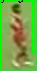

Crop 335:


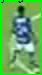

Crop 336:


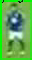

Crop 337:


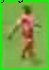

Crop 338:


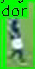

Crop 339:


Crop 340:


Crop 341:


Crop 342:


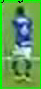

Crop 343:


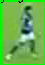

Crop 344:


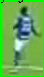

Crop 345:


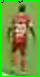

Crop 346:


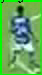

Crop 347:


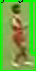

Crop 348:


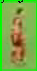

Crop 349:


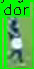

Crop 350:


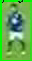

Crop 351:


Crop 352:


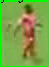

Crop 353:


Crop 354:


Crop 355:


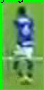

Crop 356:


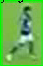

Crop 357:


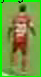

Crop 358:


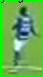

Crop 359:


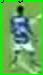

Crop 360:


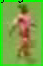

Crop 361:


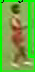

Crop 362:


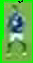

Crop 363:


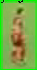

Crop 364:


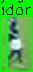

Crop 365:


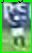

Crop 366:


Crop 367:


Crop 368:


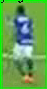

Crop 369:


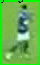

Crop 370:


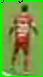

Crop 371:


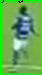

Crop 372:


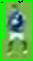

Crop 373:


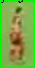

Crop 374:


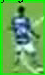

Crop 375:


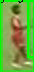

Crop 376:


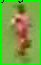

Crop 377:


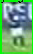

Crop 378:


Crop 379:


Crop 380:


Crop 381:


Crop 382:


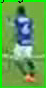

Crop 383:


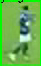

Crop 384:


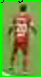

Crop 385:


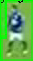

Crop 386:


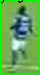

Crop 387:


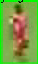

Crop 388:


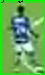

Crop 389:


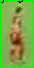

Crop 390:


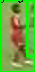

Crop 391:


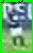

Crop 392:


Crop 393:


Crop 394:


Crop 395:


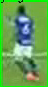

Crop 396:


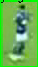

Crop 397:


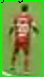

Crop 398:


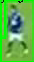

Crop 399:


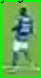

Crop 400:


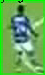

Crop 401:


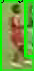

Crop 402:


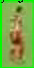

Crop 403:


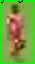

Crop 404:


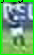

Crop 405:


Crop 406:


Crop 407:


Crop 408:


Crop 409:


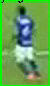

Crop 410:


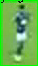

Crop 411:


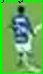

Crop 412:


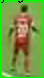

Crop 413:


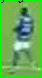

Crop 414:


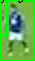

Crop 415:


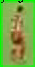

Crop 416:


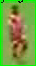

Crop 417:


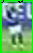

Crop 418:


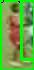

Crop 419:


Crop 420:


Crop 421:


Crop 422:


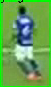

Crop 423:


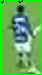

Crop 424:


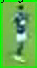

Crop 425:


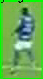

Crop 426:


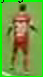

Crop 427:


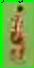

Crop 428:


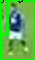

Crop 429:


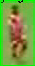

Crop 430:


Crop 431:


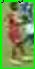

Crop 432:


Crop 433:


Crop 434:


Crop 435:


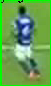

Crop 436:


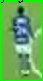

Crop 437:


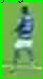

Crop 438:


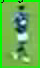

Crop 439:


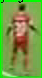

Crop 440:


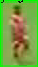

Crop 441:


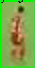

Crop 442:


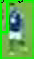

Crop 443:


Crop 444:


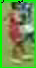

Crop 445:


Crop 446:


Crop 447:


Crop 448:


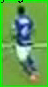

Crop 449:


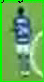

Crop 450:


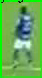

Crop 451:


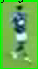

Crop 452:


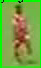

Crop 453:


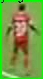

Crop 454:


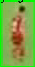

Crop 455:


Crop 456:


Crop 457:


Crop 458:


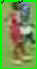

Crop 459:


Crop 460:


Crop 461:


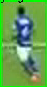

Crop 462:


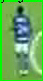

Crop 463:


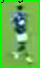

Crop 464:


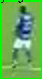

Crop 465:


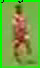

Crop 466:


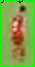

Crop 467:


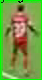

Crop 468:


Crop 469:


Crop 470:


Crop 471:


Crop 472:


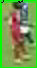

Crop 473:


Crop 474:


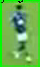

Crop 475:


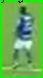

Crop 476:


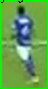

Crop 477:


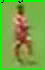

Crop 478:


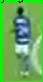

Crop 479:


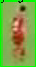

Crop 480:


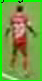

Crop 481:


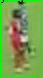

Crop 482:


Crop 483:


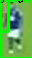

Crop 484:


Crop 485:


Crop 486:


Crop 487:


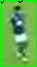

Crop 488:


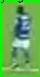

Crop 489:


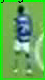

Crop 490:


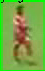

Crop 491:


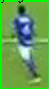

Crop 492:


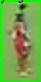

Crop 493:


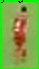

Crop 494:


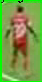

Crop 495:


Crop 496:


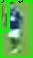

Crop 497:


Crop 498:


Crop 499:


Crop 500:


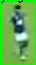

Crop 501:


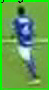

Crop 502:


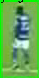

Crop 503:


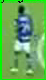

Crop 504:


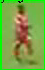

Crop 505:


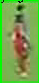

Crop 506:


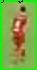

Crop 507:


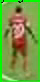

Crop 508:


Crop 509:


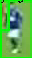

Crop 510:


Crop 511:


Crop 512:


Crop 513:


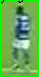

Crop 514:


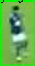

Crop 515:


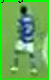

Crop 516:


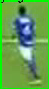

Crop 517:


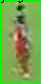

Crop 518:


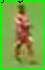

Crop 519:


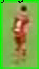

Crop 520:


Crop 521:


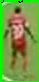

Crop 522:


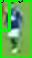

Crop 523:


Crop 524:


Crop 525:


Crop 526:


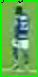

Crop 527:


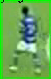

Crop 528:


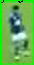

Crop 529:


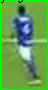

Crop 530:


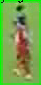

Crop 531:


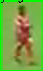

Crop 532:


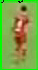

Crop 533:


Crop 534:


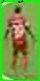

Crop 535:


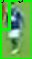

Crop 536:


Crop 537:


Crop 538:


Crop 539:


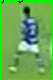

Crop 540:


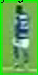

Crop 541:


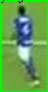

Crop 542:


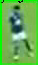

Crop 543:


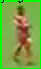

Crop 544:


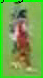

Crop 545:


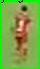

Crop 546:


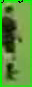

Crop 547:


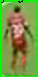

Crop 548:


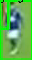

Crop 549:


Crop 550:


Crop 551:


Crop 552:


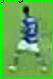

Crop 553:


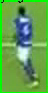

Crop 554:


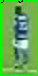

Crop 555:


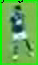

Crop 556:


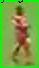

Crop 557:


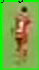

Crop 558:


Crop 559:


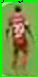

Crop 560:


Crop 561:


Crop 562:


Crop 563:


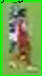

Crop 564:


Crop 565:


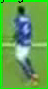

Crop 566:


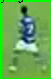

Crop 567:


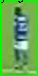

Crop 568:


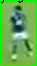

Crop 569:


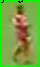

Crop 570:


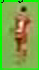

Crop 571:


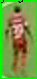

Crop 572:


Crop 573:


Crop 574:


Crop 575:


Crop 576:


Crop 577:


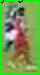

Crop 578:


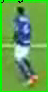

Crop 579:


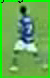

Crop 580:


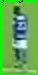

Crop 581:


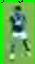

Crop 582:


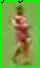

Crop 583:


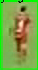

Crop 584:


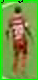

Crop 585:


Crop 586:


Crop 587:


Crop 588:


Crop 589:


Crop 590:


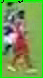

Crop 591:


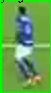

Crop 592:


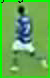

Crop 593:


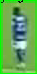

Crop 594:


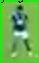

Crop 595:


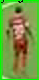

Crop 596:


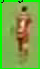

Crop 597:


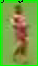

Crop 598:


Crop 599:


Crop 600:


Crop 601:


Crop 602:


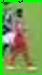

Crop 603:


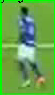

Crop 604:


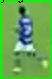

Crop 605:


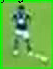

Crop 606:


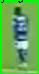

Crop 607:


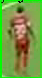

Crop 608:


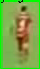

Crop 609:


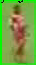

Crop 610:


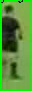

Crop 611:


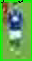

Crop 612:


In [ ]:
import cv2
from google.colab.patches import cv2_imshow

# Abrir el video
cap = cv2.VideoCapture(OUTPUT_VIDEO)
if not cap.isOpened():
    print("No se pudo abrir el video.")
    exit()

crops = []  # Lista para almacenar los recortes
frame_count = 0


valid_indices = []
crops = []
frame_count = 0

while frame_count < 50:
    ret, frame = cap.read()
    if not ret:
        break
    frame_detections = df[df['Frame'] == frame_count]
    for idx, box in zip(frame_detections.index, frame_detections['BBox']):
        x1, y1, x2, y2 = map(int, box[:4])
        crop = frame[y1:y2, x1:x2]
        if crop.size != 0:
            crops.append(crop)
            valid_indices.append(idx)  # Esto es clave, guardar el índice
    frame_count += 1

cap.release()


# Mostrar los crops
if len(crops) == 0:
    print("No se encontraron recortes en los primeros 30 frames.")
else:
    for i, crop in enumerate(crops):
        print(f"Crop {i+1}:")
        cv2_imshow(crop)

In [ ]:
!pip install scikit-learn

Number of crops per cluster:
Cluster 0: 354 crops
Cluster 1: 258 crops

Displaying one crop from Cluster 0:


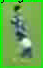


Displaying one crop from Cluster 1:


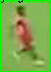

In [ ]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
from google.colab.patches import cv2_imshow

# Create feature vectors for each crop by resizing and flattening
feature_vectors = []
for crop in crops:
    # Resize the crop to a fixed size (e.g., 64x64)
    resized_crop = cv2.resize(crop, (64, 64))
    # Flatten the resized image to a 1D vector
    feature_vectors.append(resized_crop.flatten())

# Convert the list of feature vectors into a numpy array
X = np.array(feature_vectors)

# Cluster the crops into 3 groups using KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_

# Organize the crops by their cluster labels
clusters = {0: [], 1: []}
for label, crop in zip(labels, crops):
    clusters[label].append(crop)

# Print the number of crops in each cluster
print("Number of crops per cluster:")
for i in range(2):
    print(f"Cluster {i}: {len(clusters[i])} crops")

# Optionally, display one crop from each cluster
for cluster_id, crop_list in clusters.items():
    if crop_list:
        print(f"\nDisplaying one crop from Cluster {cluster_id}:")
        cv2_imshow(crop_list[0])

In [ ]:
df['Cluster'] = -1  # Inicializamos con -1 (sin cluster)
df.loc[valid_indices, 'Cluster'] = labels


In [ ]:
import cv2
import numpy as np

# Suponiendo que 'kmeans' ya está entrenado

cap = cv2.VideoCapture(OUTPUT_VIDEO)

all_crops = []
all_indices = []  # indices solo de filas con ClassName == 'jugador'

frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Filtrar detecciones sólo de 'jugador' en el frame actual
    frame_detections = df[(df['Frame'] == frame_count) & (df['ClassName'] == 'jugador')]

    for idx, box in zip(frame_detections.index, frame_detections['BBox']):
        x1, y1, x2, y2 = map(int, box[:4])
        crop = frame[y1:y2, x1:x2]
        if crop.size != 0:
            all_crops.append(crop)
            all_indices.append(idx)
    frame_count += 1

cap.release()

# Extraer features para crops válidos
feature_vectors = []
for crop in all_crops:
    resized_crop = cv2.resize(crop, (64, 64))
    feature_vectors.append(resized_crop.flatten())

X_all = np.array(feature_vectors)

# Predecir clusters solo para jugadores
labels_all = kmeans.predict(X_all)

# Inicializar clusters en -1 para todos (incluyendo otros labels)
df['Cluster'] = -1

# Asignar clusters sólo a filas de jugadores con detecciones
df.loc[all_indices, 'Cluster'] = labels_all

print(df['Cluster'].value_counts())


Cluster
 1    6545
 0    4622
-1     367
Name: count, dtype: int64


In [ ]:
df

,Frame,ClassName,BBox,Cluster
0,0,jugador,"[177.64614868164062, 278.5949401855469, 220.02...",0
1,0,jugador,"[940.1264038085938, 252.48336791992188, 984.42...",0
2,0,jugador,"[812.1710815429688, 391.4423522949219, 857.592...",0
3,0,jugador,"[52.62643814086914, 301.9477844238281, 103.787...",1
4,0,jugador,"[449.4344787597656, 225.01454162597656, 488.07...",1
...,...,...,...,...
11529,738,jugador,"[728.8328857421875, 338.194091796875, 773.2380...",1
11530,738,jugador,"[635.4104614257812, 324.90484619140625, 690.51...",0
11531,738,jugador,"[383.1383972167969, 205.45635986328125, 426.82...",0
11532,738,jugador,"[29.445457458496094, 274.7135925292969, 62.177...",0


In [ ]:
import cv2

cap = cv2.VideoCapture(OUTPUT_VIDEO)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec para mp4
out = cv2.VideoWriter('video_con_clusters_nombres.mp4', fourcc, fps, (width, height))

# Diccionario para mapear clusters a nombres y colores
cluster_names = {0: "Millonarios", 1: "America"}
cluster_colors = {0: (0, 255, 0), 1: (0, 0, 255)}

frame_index = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Filtrar detecciones para el frame actual
    detections = df[df['Frame'] == frame_index]

    for _, row in detections.iterrows():
        x1, y1, x2, y2 = map(int, row['BBox'][:4])
        cluster = int(row['Cluster'])

        if cluster in cluster_names:
            color = cluster_colors[cluster]
            label = cluster_names[cluster]

            # Dibujar el bounding box
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            # Poner texto con el nombre del cluster
            cv2.putText(frame, label, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    out.write(frame)
    frame_index += 1

cap.release()
out.release()

print("Video creado: video_con_clusters_nombres.mp4")


Video creado: video_con_clusters_nombres.mp4


In [ ]:
def bbox_center(box):
    x1, y1, x2, y2 = map(float, box[:4])
    return ((x1 + x2) / 2, (y1 + y2) / 2)


In [ ]:
import cv2
import numpy as np

# Definimos nombres y colores por cluster
cluster_names = {0: "Millonarios", 1: "America"}
cluster_colors = {
    0: (255, 0, 0),   # Azul para Millonarios (BGR)
    1: (0, 0, 255)    # Rojo para América (BGR)
}

dist_threshold = 36  # Distancia máxima para considerar tenencia del balón
passes_count = {0: 0, 1: 0}
min_frames_between_passes = 15  # Para evitar múltiples conteos rápidos

def bbox_center(box):
    x1, y1, x2, y2 = map(int, box[:4])
    return ((x1 + x2) // 2, (y1 + y2) // 2)

# Cargar el video
cap = cv2.VideoCapture(OUTPUT_VIDEO)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Inicializar salida
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('video_rtrg3.mp4', fourcc, fps, (width, height))

prev_holder = None
last_pass_frame = -min_frames_between_passes
frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_data = df[df['Frame'] == frame_count]

    # Obtener posición del balón
    balon_data = frame_data[frame_data['ClassName'] == 'balon']
    balon_pos = None
    if not balon_data.empty:
        balon_pos = bbox_center(balon_data.iloc[0]['BBox'])
        cv2.circle(frame, balon_pos, 10, (255, 255, 255), -1)

    # Obtener jugadores con cluster válido
    players = frame_data[(frame_data['ClassName'] == 'jugador') & (frame_data['Cluster'] != -1)]

    current_holder = None
    min_dist = float('inf')

    for idx, row in players.iterrows():
        cluster = row['Cluster']
        name = cluster_names.get(cluster, "Unknown")
        color = cluster_colors.get(cluster, (0, 255, 255))

        x1, y1, x2, y2 = map(int, row['BBox'][:4])

        # Dibuja bounding box y nombre del equipo
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(frame, name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, color, 2)

        if balon_pos is not None:
            player_center = bbox_center(row['BBox'])
            dist = np.linalg.norm(np.array(balon_pos) - np.array(player_center))
            if dist < min_dist:
                min_dist = dist
                current_holder = (cluster, idx, player_center)

    # Si está muy lejos de todos, asumimos que nadie tiene el balón
    if min_dist > dist_threshold:
        current_holder = None

    # Detección de pase dentro del mismo cluster (equipo)
    if (prev_holder is not None and current_holder is not None and
        frame_count - last_pass_frame > min_frames_between_passes):

        if prev_holder[0] == current_holder[0] and prev_holder[1] != current_holder[1]:
            team_cluster = current_holder[0]
            passes_count[team_cluster] += 1
            last_pass_frame = frame_count
            line_color = cluster_colors[team_cluster]
            cv2.line(frame, prev_holder[2], current_holder[2], line_color, 3)
            cv2.putText(frame, 'Pase!', (current_holder[2][0], current_holder[2][1] - 15),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, line_color, 2)

    prev_holder = current_holder

    # Mostrar conteo de pases por equipo
    cv2.putText(frame, f"Millonarios pases: {passes_count[0]}", (20, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, cluster_colors[0], 2)
    cv2.putText(frame, f"América pases: {passes_count[1]}", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 1, cluster_colors[1], 2)

    out.write(frame)
    frame_count += 1

cap.release()
out.release()
print("✅ Video con pases y colores generado: video_pases_colores.mp4")


✅ Video con pases y colores generado: video_pases_colores.mp4


In [ ]:
import cv2
import numpy as np

# Nombres y colores por cluster
cluster_names = {0: "Millonarios", 1: "America"}
cluster_colors = {
    0: (255, 0, 0),   # Azul
    1: (0, 0, 255)    # Rojo
}

dist_threshold = 36
passes_count = {0: 0, 1: 0}
goals_count = {0: 0, 1: 0}
min_frames_between_passes = 15
min_frames_between_goals = 5

def bbox_center(box):
    x1, y1, x2, y2 = map(int, box[:4])
    return ((x1 + x2) // 2, (y1 + y2) // 2)

def is_inside_bbox(point, bbox):
    x, y = point
    x1, y1, x2, y2 = map(int, bbox[:4])
    return x1 <= x <= x2 and y1 <= y <= y2

cap = cv2.VideoCapture(OUTPUT_VIDEO)
fps = cap.get(cv2.CAP_PROP_FPS)
width, height = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('Proyecto_final_deep_learning.mp4', fourcc, fps, (width, height))

prev_holder = None
last_pass_frame = -min_frames_between_passes
last_goal_frame = -min_frames_between_goals
frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_data = df[df['Frame'] == frame_count]
    balon_data = frame_data[frame_data['ClassName'] == 'balon']
    arco_data = frame_data[frame_data['ClassName'] == 'arco']

    balon_pos = None
    if not balon_data.empty:
        balon_pos = bbox_center(balon_data.iloc[0]['BBox'])
        cv2.circle(frame, balon_pos, 10, (255, 255, 255), -1)

    players = frame_data[(frame_data['ClassName'] == 'jugador') & (frame_data['Cluster'] != -1)]
    current_holder = None
    min_dist = float('inf')

    for idx, row in players.iterrows():
        cluster = row['Cluster']
        name = cluster_names[cluster]
        color = cluster_colors[cluster]
        x1, y1, x2, y2 = map(int, row['BBox'][:4])
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(frame, name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)




        if balon_pos is not None:
            player_center = bbox_center(row['BBox'])
            dist = np.linalg.norm(np.array(balon_pos) - np.array(player_center))
            if dist < min_dist:
                min_dist = dist
                current_holder = (cluster, idx, player_center)

    if min_dist > dist_threshold:
        current_holder = None

    if (prev_holder and current_holder and frame_count - last_pass_frame > min_frames_between_passes):
        if prev_holder[0] == current_holder[0] and prev_holder[1] != current_holder[1]:
            passes_count[current_holder[0]] += 1
            last_pass_frame = frame_count
            color = cluster_colors[current_holder[0]]
            cv2.line(frame, prev_holder[2], current_holder[2], color, 3)
            cv2.putText(frame, 'Pase!', (current_holder[2][0], current_holder[2][1] - 15),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    # Detección de goles
    if balon_pos is not None and frame_count - last_goal_frame > min_frames_between_goals:
        for _, arco in arco_data.iterrows():
            arco_bbox = arco['BBox']
            if is_inside_bbox(balon_pos, arco_bbox):
                if arco_bbox[0] < width // 2:
                    goals_count[1] += 1  # América anota
                else:
                    goals_count[0] += 1  # Millonarios anota
                last_goal_frame = frame_count
                cv2.putText(frame, 'GOOOL!', (balon_pos[0], balon_pos[1] - 20),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 255), 3)

    prev_holder = current_holder

    cv2.putText(frame, f"Millonarios pases: {passes_count[0]}", (20, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, cluster_colors[0], 2)
    cv2.putText(frame, f"America pases: {passes_count[1]}", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 1, cluster_colors[1], 2)

    cv2.putText(frame, f"Goles Millonarios: {goals_count[0]}", (20, 110),
                cv2.FONT_HERSHEY_SIMPLEX, 1, cluster_colors[0], 2)
    cv2.putText(frame, f"Goles America: {goals_count[1]}", (20, 150),
                cv2.FONT_HERSHEY_SIMPLEX, 1, cluster_colors[1], 2)

    out.write(frame)
    frame_count += 1

cap.release()
out.release()
print("✅ Video generado con pases y goles: video_pases_y_goles.mp4")


✅ Video generado con pases y goles: video_pases_y_goles.mp4
